# Step 9 – K-Means Clustering: City Roles in the Open-AI Ecosystem

**RQ1**: *What distinct roles do global cities play in the ecosystem of prominent open-AI projects, such as originators, collaboration hubs, bridge cities, and late adopters?*

This notebook:
1. Selects and transforms clustering variables based on EDA findings
2. Determines the optimal number of clusters (elbow + silhouette)
3. Fits K-means and interprets each cluster as a city role
4. Visualises results on a global map and via radar / profile charts

In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

DATA = Path('..') / 'data' / 'output'
city_attr = pd.read_csv(DATA / 'city_attributes.csv')
print(f'Loaded {len(city_attr)} cities × {city_attr.shape[1]} columns')

Loaded 148 cities × 26 columns


## 9.1 – Feature Selection & Transformation

Based on EDA findings:
- `collaboration_count` ≡ `weighted_degree` (ρ = 1.0) → keep only `weighted_degree`
- Activity variables are heavily right-skewed → apply `log1p`
- All inputs must be z-score standardised for K-means
- Include both absolute-scale and per-capita indicators to capture distinct role dimensions

In [18]:
# Select clustering features
# Dimension 1: Innovation intensity (origination)
# Dimension 2: Adoption breadth
# Dimension 3: Network position (hub vs periphery)
# Dimension 4: Bridge role (betweenness)
# Dimension 5: Per-capita innovation (captures small but intense cities)

df = city_attr.copy()

# Apply log1p to skewed absolute variables
df['log_origination'] = np.log1p(df['origination_count'])
df['log_adoption']    = np.log1p(df['adoption_count'])
df['log_degree']      = np.log1p(df['weighted_degree'])
df['log_betweenness'] = np.log1p(df['betweenness'] * 1000)  # scale up before log
df['log_orig_rate']   = np.log1p(df['origination_rate_pop'])

cluster_features = [
    'log_origination',   # innovation volume
    'log_adoption',      # adoption breadth
    'log_degree',        # network centrality
    'log_betweenness',   # bridge / intermediary role
    'log_orig_rate',     # per-capita innovation intensity
]

X_raw = df[cluster_features].copy()
print('Clustering features (after log1p):')
print(X_raw.describe().round(3).to_string())
print(f'\nSkewness:')
for c in cluster_features:
    print(f'  {c:25s}  {X_raw[c].skew():+.2f}')

Clustering features (after log1p):
       log_origination  log_adoption  log_degree  log_betweenness  log_orig_rate
count          148.000       148.000     148.000          148.000        143.000
mean             2.366         4.787       7.210            1.302          1.665
std              1.640         1.220       1.080            1.110          1.567
min              0.000         1.386       4.174            0.000          0.000
25%              1.099         4.003       6.552            0.373          0.461
50%              2.197         4.738       7.151            0.997          1.169
75%              3.178         5.554       7.948            1.970          2.330
max              7.497         8.232       9.498            4.831          8.543

Skewness:
  log_origination            +0.79
  log_adoption               +0.25
  log_degree                 -0.21
  log_betweenness            +0.90
  log_orig_rate              +1.42


In [19]:
# Drop rows with NaN (some cities lack population data for origination_rate_pop)
X_raw = X_raw.dropna()
print(f'Rows after dropping NaN: {len(X_raw)} (dropped {len(df) - len(X_raw)})')

# Standardise (z-score)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_df = pd.DataFrame(X, columns=cluster_features, index=X_raw.index)

print('\nAfter standardisation:')
print(X_df.describe().round(3).to_string())

Rows after dropping NaN: 143 (dropped 5)

After standardisation:
       log_origination  log_adoption  log_degree  log_betweenness  log_orig_rate
count          143.000       143.000     143.000          143.000        143.000
mean             0.000        -0.000       0.000            0.000         -0.000
std              1.004         1.004       1.004            1.004          1.004
min             -1.471        -2.937      -2.996           -1.176         -1.066
25%             -0.797        -0.666      -0.659           -0.838         -0.771
50%             -0.124        -0.021      -0.063           -0.279         -0.317
75%              0.477         0.611       0.681            0.597          0.426
max              3.124         2.876       2.160            3.418          4.404


## 9.2 – Optimal k Selection

  k= 2  inertia=   360.5  silhouette=0.3985
  k= 3  inertia=   231.8  silhouette=0.3858
  k= 4  inertia=   185.3  silhouette=0.3480
  k= 5  inertia=   151.3  silhouette=0.3728
  k= 6  inertia=   131.2  silhouette=0.3644
  k= 7  inertia=   112.9  silhouette=0.3348
  k= 8  inertia=    96.6  silhouette=0.3315
  k= 9  inertia=    86.1  silhouette=0.3167
  k=10  inertia=    80.0  silhouette=0.3113


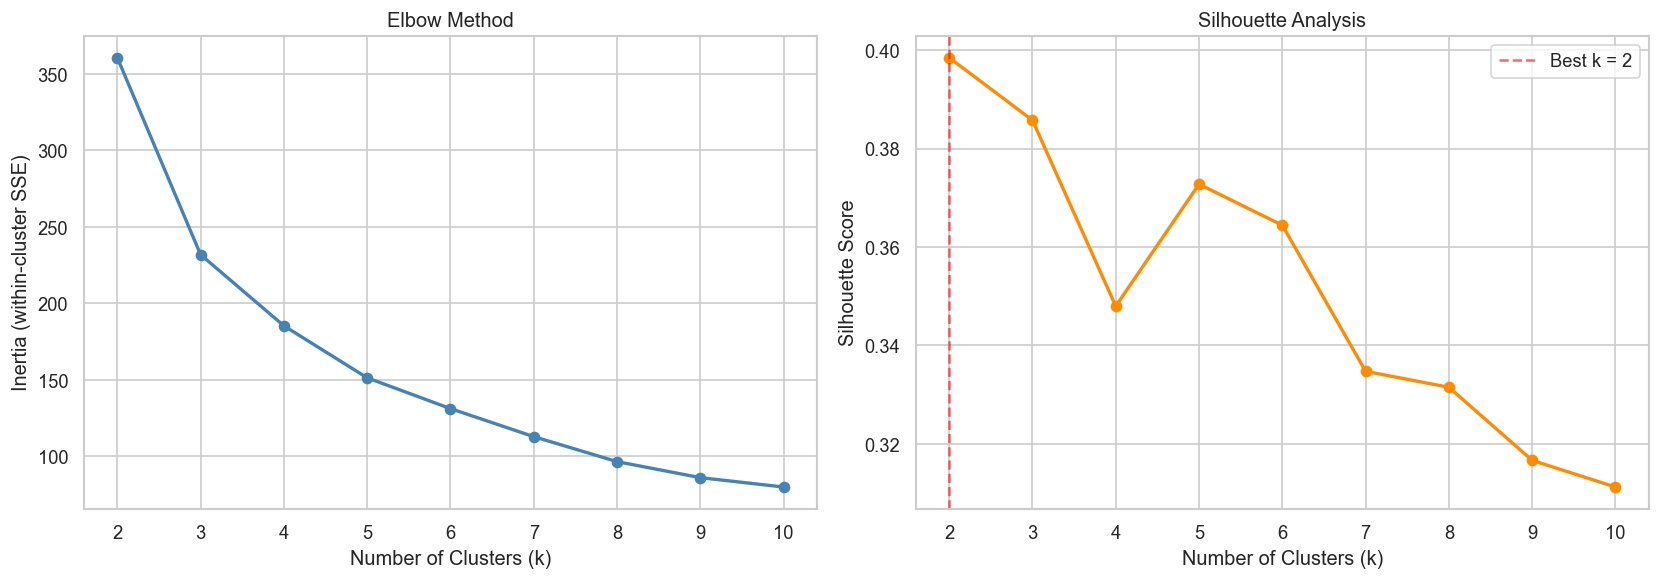


Best silhouette at k = 2 (0.3985)


In [20]:
# Elbow method + Silhouette score
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouettes.append(sil)
    print(f'  k={k:2d}  inertia={km.inertia_:8.1f}  silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouettes, 'o-', color='darkorange', lw=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(K_range))

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', ls='--', alpha=0.6,
                label=f'Best k = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nBest silhouette at k = {best_k} ({max(silhouettes):.4f})')

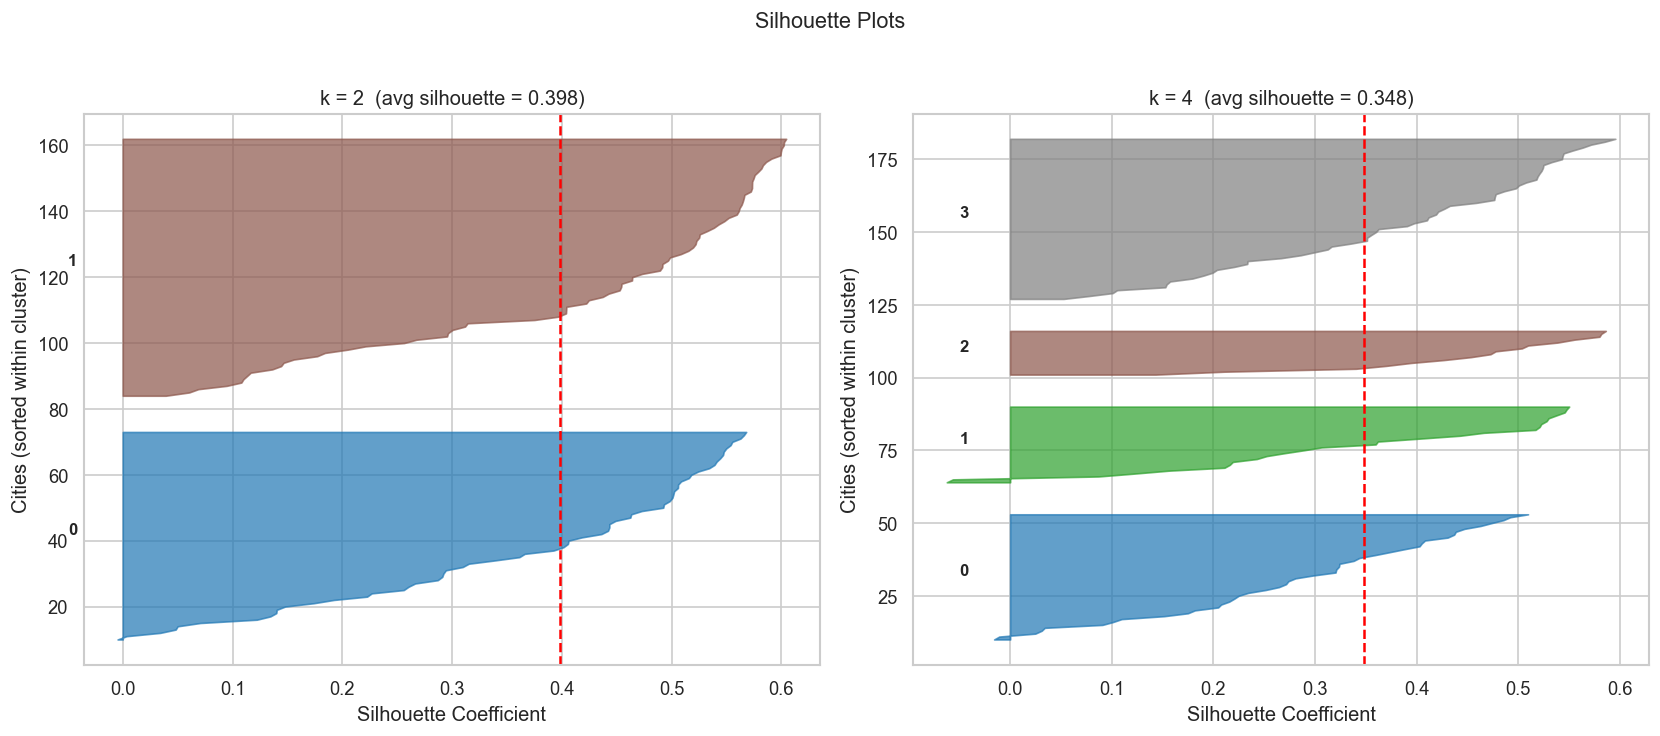

In [21]:
# Silhouette plot for the chosen k
# We test both the silhouette-optimal k and k=4 (theory-driven: 4 roles)
test_ks = sorted(set([best_k, 4]))

fig, axes = plt.subplots(1, len(test_ks), figsize=(7 * len(test_ks), 6))
if len(test_ks) == 1:
    axes = [axes]

for ax, k in zip(axes, test_ks):
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    avg_sil = silhouette_score(X, labels)

    y_lower = 10
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = plt.cm.tab10(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='red', ls='--', lw=1.5)
    ax.set_title(f'k = {k}  (avg silhouette = {avg_sil:.3f})', fontsize=12)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cities (sorted within cluster)')

plt.suptitle('Silhouette Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9.3 – Final Clustering (k = 4)

We use **k = 4** as our primary model, matching the four theoretically motivated roles:
originators, collaboration hubs, bridge cities, and peripheral / late adopters.
If the silhouette-optimal k differs, we compare both.

In [22]:
CHOSEN_K = 4

km_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=500)
labels = km_final.fit_predict(X)

df['cluster'] = np.nan
df.loc[X_raw.index, 'cluster'] = labels

print(f'Cluster sizes (k = {CHOSEN_K}):')
print(df['cluster'].value_counts().sort_index().to_string())
print(f'\nSilhouette score: {silhouette_score(X, labels):.4f}')

Cluster sizes (k = 4):
cluster
0.0    44
1.0    27
2.0    16
3.0    56

Silhouette score: 0.3480


In [23]:
# Cluster profiles: mean of original (untransformed) variables
profile_cols = [
    'origination_count', 'adoption_count', 'weighted_degree',
    'betweenness', 'origination_rate_pop', 'adoption_rate_pop',
    'collaboration_rate_pop', 'avg_lag', 'entity_count',
    'population_million', 'gdp_per_capita', 'research_capacity',
]

profiles = df.groupby('cluster')[profile_cols].mean().round(2)
profiles['n_cities'] = df.groupby('cluster').size()

print('Cluster Profiles (mean values):')
display(profiles.T)

Cluster Profiles (mean values):


cluster,0.0,1.0,2.0,3.0
origination_count,3.80,275.37,1.62,14.55
adoption_count,59.55,942.07,22.38,187.71
weighted_degree,793.34,6353.07,257.75,2247.23
betweenness,0.01,0.00,0.03,0.00
origination_rate_pop,6.66,282.03,1.00,7.20
adoption_rate_pop,84.59,742.77,12.26,86.53
collaboration_rate_pop,1072.72,5982.10,134.76,1061.71
avg_lag,9.32,5.61,9.97,8.80
entity_count,42.95,671.52,16.81,134.71
population_million,4.78,8.73,6.98,6.59


In [24]:
# Assign interpretive role labels based on cluster profiles
# Sort clusters by origination_count descending to assign labels
cluster_order = profiles.sort_values('origination_count', ascending=False).index.tolist()

# Heuristic label assignment:
# Highest origination + adoption + degree → "Global Innovation Hub"
# Second highest, high collaboration → "Active Collaborator"
# Moderate activity, possibly high per-capita → "Emerging Contributor"
# Lowest activity → "Peripheral / Late Adopter"

role_names_ordered = [
    'Global Innovation Hub',
    'Active Collaborator',
    'Emerging Contributor',
    'Peripheral / Late Adopter',
]

role_map = {}
for i, cluster_id in enumerate(cluster_order):
    if i < len(role_names_ordered):
        role_map[cluster_id] = role_names_ordered[i]
    else:
        role_map[cluster_id] = f'Cluster {cluster_id}'

df['role'] = df['cluster'].map(role_map)

print('Role assignments:')
for cid, role in sorted(role_map.items()):
    n = (df['cluster'] == cid).sum()
    mean_orig = df.loc[df['cluster'] == cid, 'origination_count'].mean()
    mean_adopt = df.loc[df['cluster'] == cid, 'adoption_count'].mean()
    mean_deg = df.loc[df['cluster'] == cid, 'weighted_degree'].mean()
    print(f'  Cluster {cid} → {role:30s}  (n={n:3d}, '
          f'orig={mean_orig:.0f}, adopt={mean_adopt:.0f}, degree={mean_deg:.0f})')

Role assignments:
  Cluster 0.0 → Emerging Contributor            (n= 44, orig=4, adopt=60, degree=793)
  Cluster 1.0 → Global Innovation Hub           (n= 27, orig=275, adopt=942, degree=6353)
  Cluster 2.0 → Peripheral / Late Adopter       (n= 16, orig=2, adopt=22, degree=258)
  Cluster 3.0 → Active Collaborator             (n= 56, orig=15, adopt=188, degree=2247)


## 9.4 – Cluster Visualisation

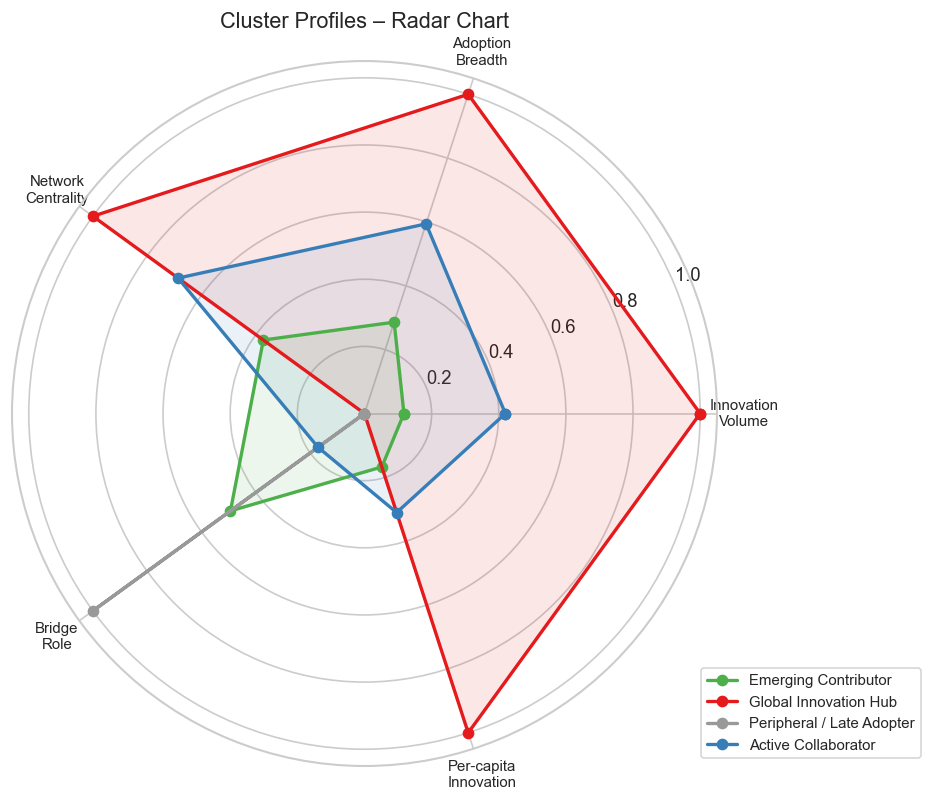

In [25]:
# Radar / spider chart: normalised cluster centroids
radar_cols = ['log_origination', 'log_adoption', 'log_degree',
              'log_betweenness', 'log_orig_rate']
radar_labels = ['Innovation\nVolume', 'Adoption\nBreadth', 'Network\nCentrality',
                'Bridge\nRole', 'Per-capita\nInnovation']

centroids_std = pd.DataFrame(km_final.cluster_centers_, columns=cluster_features)
# Min-max normalise centroids to [0, 1] for radar
centroids_norm = (centroids_std - centroids_std.min()) / (centroids_std.max() - centroids_std.min() + 1e-9)

n_vars = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

role_colors = {
    'Global Innovation Hub': '#e41a1c',
    'Active Collaborator': '#377eb8',
    'Emerging Contributor': '#4daf4a',
    'Peripheral / Late Adopter': '#999999',
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cid in range(CHOSEN_K):
    role = role_map[cid]
    vals = centroids_norm.iloc[cid][radar_cols].tolist()
    vals += vals[:1]
    color = role_colors.get(role, 'grey')
    ax.plot(angles, vals, 'o-', lw=2, label=role, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_title('Cluster Profiles – Radar Chart', fontsize=13, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=9)
plt.tight_layout()
plt.show()

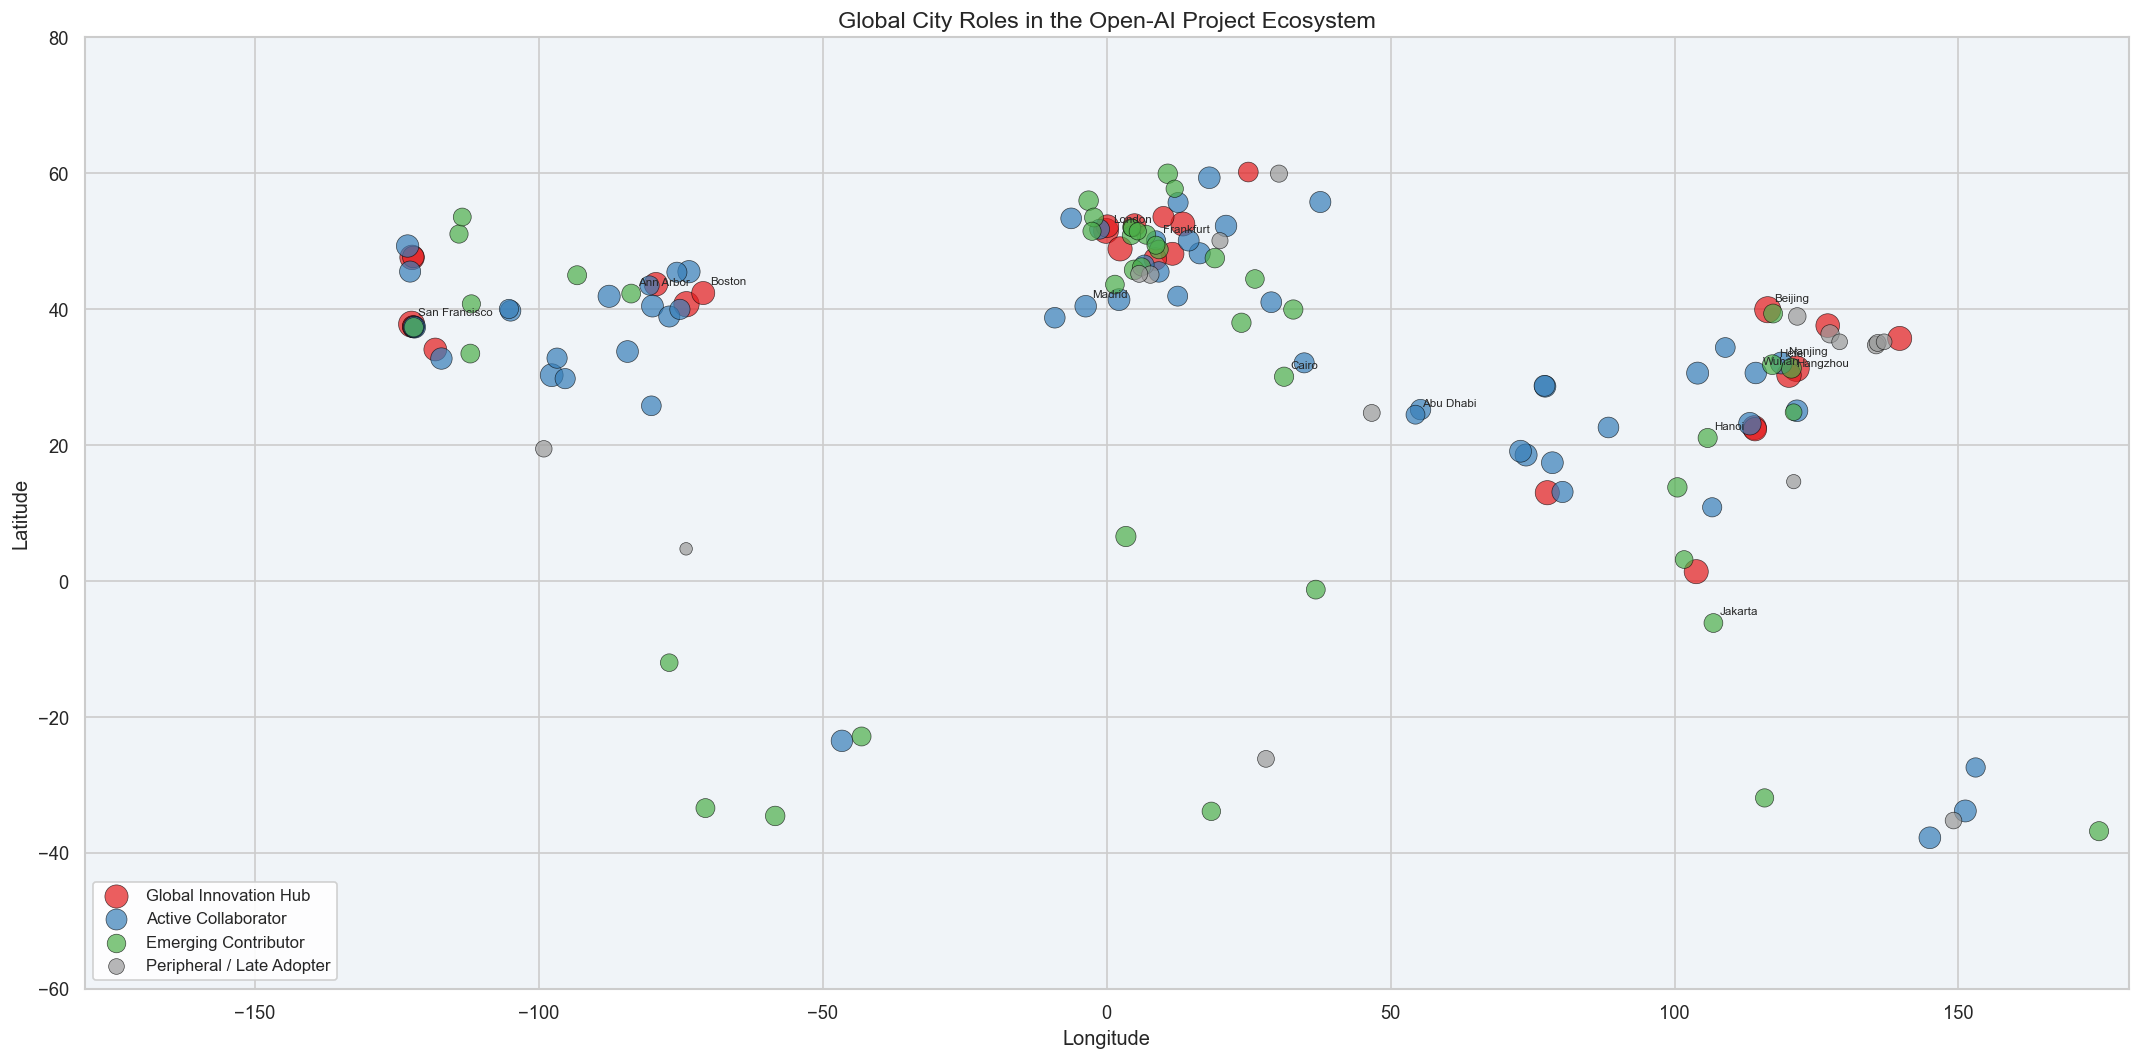

In [26]:
# Global map: cities coloured by cluster role
fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#f0f4f8')
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)

# Bubble size ~ log(entity_count)
sizes = np.log1p(df['entity_count']) * 30 + 15

for role in role_names_ordered:
    mask = df['role'] == role
    color = role_colors.get(role, 'grey')
    ax.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'],
               s=sizes[mask], c=color, alpha=0.7,
               edgecolors='black', linewidths=0.4, label=role, zorder=3)

# Label top cities per cluster
for role in role_names_ordered[:3]:  # label top roles
    subset = df[df['role'] == role].nlargest(5, 'origination_count')
    for _, row in subset.iterrows():
        ax.annotate(row['city'], (row['lon'], row['lat']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Global City Roles in the Open-AI Project Ecosystem', fontsize=14)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

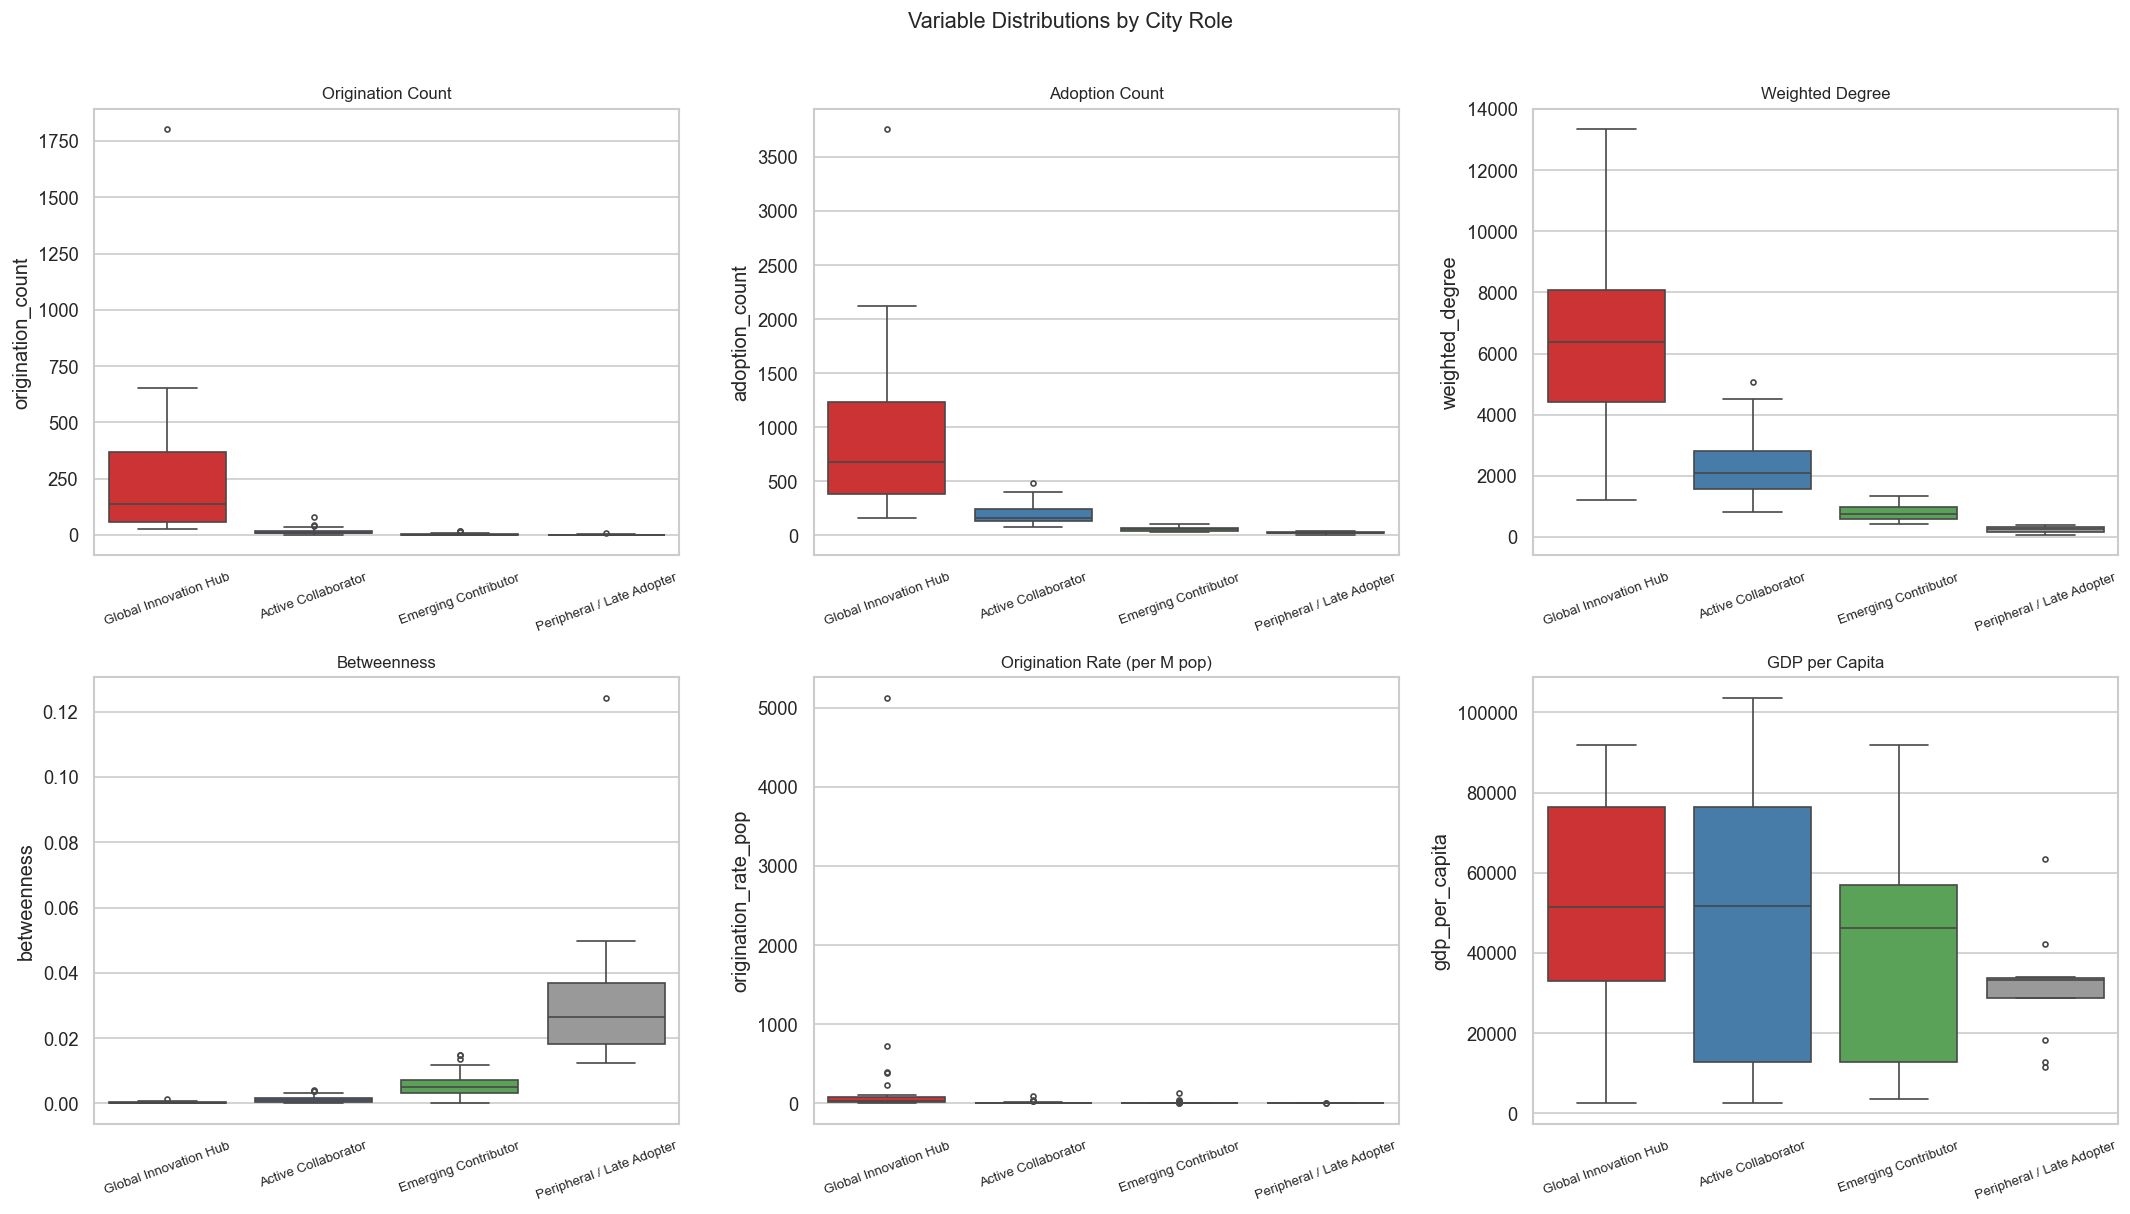

In [27]:
# Box plots: key variables by role
box_vars = [
    ('origination_count', 'Origination Count'),
    ('adoption_count', 'Adoption Count'),
    ('weighted_degree', 'Weighted Degree'),
    ('betweenness', 'Betweenness'),
    ('origination_rate_pop', 'Origination Rate (per M pop)'),
    ('gdp_per_capita', 'GDP per Capita'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, title) in zip(axes.flatten(), box_vars):
    order = role_names_ordered
    palette = [role_colors[r] for r in order]
    sns.boxplot(data=df, x='role', y=col, order=order, palette=palette,
                ax=ax, fliersize=3)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.set_xlabel('')

plt.suptitle('Variable Distributions by City Role', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

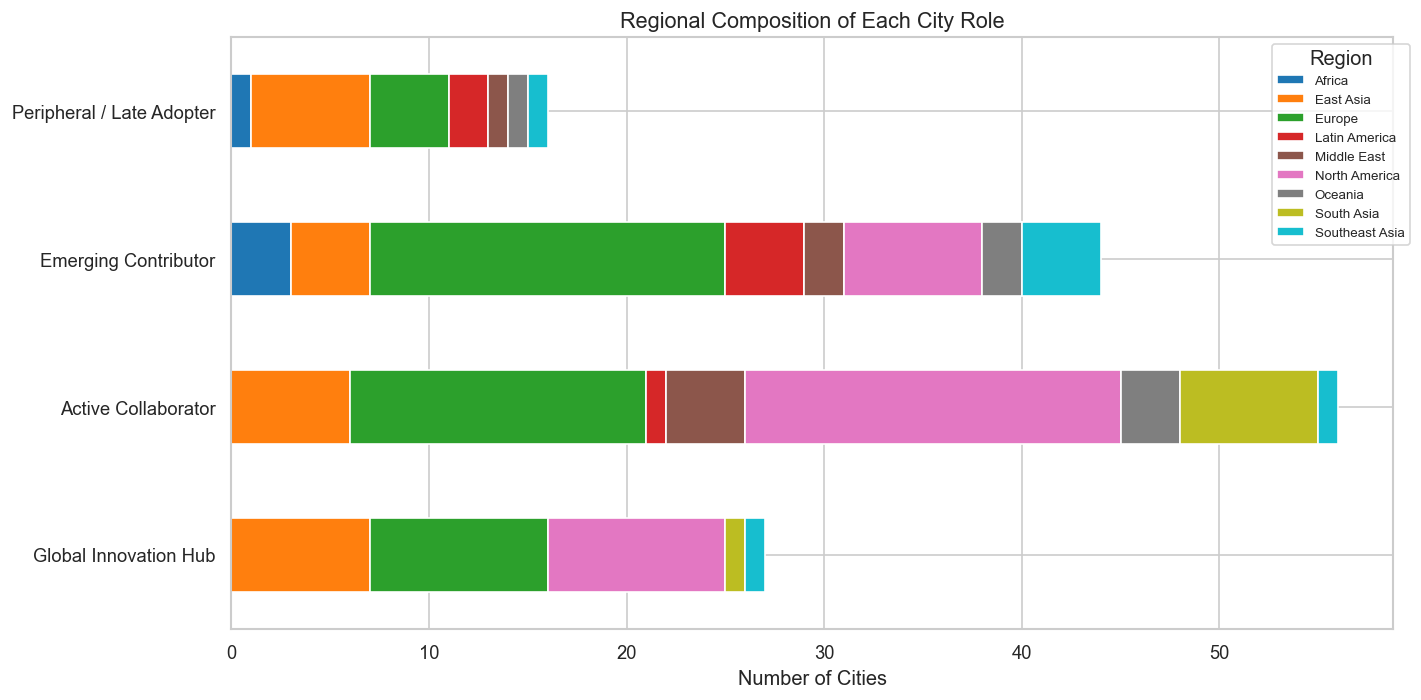

Regional composition:


region,Africa,East Asia,Europe,Latin America,Middle East,North America,Oceania,South Asia,Southeast Asia
role,,,,,,,,,
Global Innovation Hub,0,7,9,0,0,9,0,1,1
Active Collaborator,0,6,15,1,4,19,3,7,1
Emerging Contributor,3,4,18,4,2,7,2,0,4
Peripheral / Late Adopter,1,6,4,2,1,0,1,0,1


In [28]:
# Regional composition of each cluster
role_region = pd.crosstab(df['role'], df['region'])
role_region = role_region.loc[role_names_ordered]

fig, ax = plt.subplots(figsize=(12, 6))
role_region.plot.barh(stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Regional Composition of Each City Role', fontsize=13)
ax.set_xlabel('Number of Cities')
ax.set_ylabel('')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

print('Regional composition:')
display(role_region)

In [29]:
# List representative cities in each cluster
print('=' * 70)
print('REPRESENTATIVE CITIES BY ROLE')
print('=' * 70)

for role in role_names_ordered:
    subset = df[df['role'] == role].sort_values('origination_count', ascending=False)
    n = len(subset)
    top_cities = subset.head(min(10, n))

    print(f'\n▸ {role} ({n} cities)')
    for _, row in top_cities.iterrows():
        print(f'    {row["city"]:20s} ({row["country"]:15s})  '
              f'orig={row["origination_count"]:5.0f}  '
              f'adopt={row["adoption_count"]:6.0f}  '
              f'degree={row["weighted_degree"]:7.0f}')

REPRESENTATIVE CITIES BY ROLE

▸ Global Innovation Hub (27 cities)
    San Francisco        (United States  )  orig= 1802  adopt=  3757  degree=  13337
    Beijing              (China          )  orig=  653  adopt=  2126  degree=  10471
    London               (United Kingdom )  orig=  633  adopt=  1784  degree=  10389
    Hangzhou             (China          )  orig=  533  adopt=  1233  degree=   6463
    Boston               (United States  )  orig=  513  adopt=   910  degree=   5051
    New York             (United States  )  orig=  496  adopt=  1594  degree=  11214
    Seattle              (United States  )  orig=  382  adopt=  1226  degree=   8762
    Redmond              (United States  )  orig=  359  adopt=   478  degree=   2357
    Paris                (France         )  orig=  288  adopt=   934  degree=   7000
    Shanghai             (China          )  orig=  269  adopt=  1416  degree=   9198

▸ Active Collaborator (56 cities)
    Frankfurt            (Germany        )  orig

## 9.5 – Save Results

In [30]:
# Save cluster assignments back to city_attributes
city_attr['cluster'] = df['cluster']
city_attr['role'] = df['role']
city_attr.to_csv(DATA / 'city_attributes.csv', index=False)
print(f'✅ Saved cluster & role columns to city_attributes.csv')

print(f'\n📊 Final cluster summary:')
summary = df.groupby('role').agg(
    n_cities=('city', 'count'),
    mean_origination=('origination_count', 'mean'),
    mean_adoption=('adoption_count', 'mean'),
    mean_degree=('weighted_degree', 'mean'),
    mean_betweenness=('betweenness', 'mean'),
    mean_gdp=('gdp_per_capita', 'mean'),
    top_city=('origination_count', lambda x: df.loc[x.idxmax(), 'city']),
).round(2)
display(summary)

✅ Saved cluster & role columns to city_attributes.csv

📊 Final cluster summary:


,n_cities,mean_origination,mean_adoption,mean_degree,mean_betweenness,mean_gdp,top_city
role,,,,,,,
Active Collaborator,56,14.55,187.71,2247.23,0.00,44844.71,Frankfurt
Emerging Contributor,44,3.80,59.55,793.34,0.01,41626.29,Hanoi
Global Innovation Hub,27,275.37,942.07,6353.07,0.00,49953.33,San Francisco
Peripheral / Late Adopter,16,1.62,22.38,257.75,0.03,31750.50,Daejeon
